# UNSW-NB15 Multi-Class Classification

This notebook evaluates multiple models for multi-class prediction using the `attack_cat` label.
Models compared: Logistic Regression, Decision Tree, Random Forest, and XGBoost.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Preprocessing

In [2]:
train_path = r'../Datasets/USNW/UNSW_NB15_training-set.parquet'
test_path = r'../Datasets/USNW/UNSW_NB15_testing-set.parquet'

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

# Drop binary 'label' and 'id' as we focus on 'attack_cat'
for col in ['id', 'label']:
    if col in train_df.columns: train_df = train_df.drop(col, axis=1)
    if col in test_df.columns: test_df = test_df.drop(col, axis=1)

# Handle missing values in attack_cat (representing normal traffic)
train_df['attack_cat'] = train_df['attack_cat'].fillna('Normal').astype(str).str.strip()
test_df['attack_cat'] = test_df['attack_cat'].fillna('Normal').astype(str).str.strip()

X_train = train_df.drop('attack_cat', axis=1)
y_train = train_df['attack_cat']
X_test = test_df.drop('attack_cat', axis=1)
y_test = test_df['attack_cat']

print("Target Distribution:\n", y_train.value_counts())

Target Distribution:
 attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [3]:
# Encode categorical features
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
    le = LabelEncoder()
    unique_vals = list(set(X_train[col].astype(str).unique()) | set(X_test[col].astype(str).unique()))
    le.fit(unique_vals)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# Scale numerical features
numerical_cols = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Encode target variable
target_encoder = LabelEncoder()
target_encoder.fit(list(set(y_train.unique()) | set(y_test.unique())))
y_train_enc = target_encoder.transform(y_train)
y_test_enc = target_encoder.transform(y_test)

## 2. Model Training & Comparison

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, objective='multi:softmax', num_class=len(target_encoder.classes_))
}

results = []
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train_enc)
    
    preds = model.predict(X_test)
    acc = accuracy_score(y_test_enc, preds)
    prec = precision_score(y_test_enc, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test_enc, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test_enc, preds, average='weighted', zero_division=0)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Weighted Precision': prec,
        'Weighted Recall': rec,
        'Weighted F1': f1
    })
    print(f"{name} - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")

results_df = pd.DataFrame(results)
display(results_df)

Training Logistic Regression...
Logistic Regression - Acc: 0.6627, Prec: 0.7264, Rec: 0.6627, F1: 0.6694
Training Decision Tree...
Decision Tree - Acc: 0.7415, Prec: 0.7964, Rec: 0.7415, F1: 0.7610
Training Random Forest...
Random Forest - Acc: 0.7710, Prec: 0.8214, Rec: 0.7710, F1: 0.7822
Training XGBoost...
XGBoost - Acc: 0.7862, Prec: 0.8297, Rec: 0.7862, F1: 0.7860


,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,Logistic Regression,0.662707,0.726441,0.662707,0.669439
1,Decision Tree,0.741486,0.796434,0.741486,0.761013
2,Random Forest,0.771025,0.821405,0.771025,0.782238
3,XGBoost,0.786171,0.829741,0.786171,0.785984


## 3. Visualizing Results

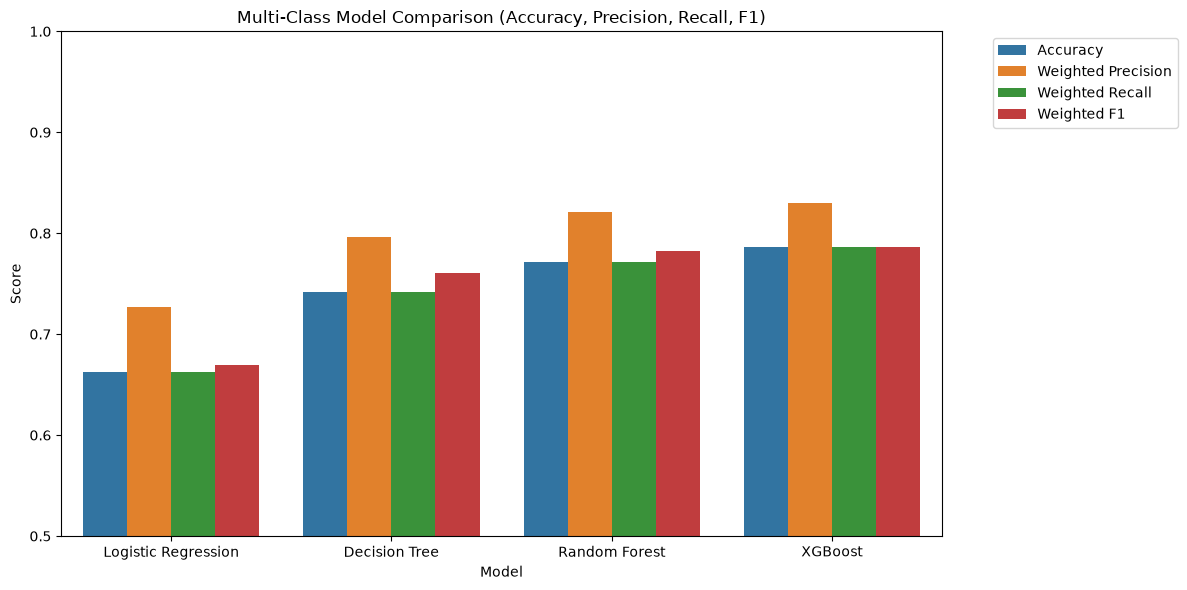

In [5]:
plt.figure(figsize=(12, 6))
melted_df = results_df.melt(id_vars='Model', value_vars=['Accuracy', 'Weighted Precision', 'Weighted Recall', 'Weighted F1'], var_name='Metric', value_name='Score')
sns.barplot(data=melted_df, x='Model', y='Score', hue='Metric')
plt.title('Multi-Class Model Comparison (Accuracy, Precision, Recall, F1)')
plt.ylim(0.5, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()